<a href="https://colab.research.google.com/github/rmkenv/LinkedinWorks/blob/main/GA_Energy_Cost_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Georgia Residential Energy Cost Predictor
## Census tract features -> Gradient Boosting -> Predicted annual energy cost & burden

**Built by Ryan Kmetz

---

### What this notebook does

1. **Pulls** ACS 5-Year 2023 tract-level features (housing age, fuel type, building type mix, income)
2. **Builds** a tract-level energy cost estimate using NREL ResStock 2025 R1 unit costs weighted by building type
3. **Engineers features** for ML
4. **Trains a Gradient Boosting Regressor** to predict annual energy cost per housing unit
5. **Evaluates** model (R2, MAE, feature importance)
6. **Maps** predicted energy cost and energy burden across all Georgia tracts

> **Energy burden** = predicted annual cost / median household income x 100  
> HUD defines >= 6% as 'severe' energy burden.

### Data sources

| Source | Role |
|---|---|
| ResStock 2025 R1 (NREL / OEDI S3) | Modelled baseline energy consumption by building type |
| ACS 5-Year 2023 (Census API) | Tract features: income, housing age, fuel shares, unit counts |
| EIA 2023 GA average rates | $/kWh electricity, $/therm gas, $/gallon propane |
| TIGER/Line 2023 (Census) | Georgia tract boundaries for choropleth |


## 0 · Install & import

In [1]:
!pip install -q requests pandas numpy scikit-learn boto3 pyarrow matplotlib seaborn folium geopandas

import warnings
warnings.filterwarnings('ignore')

import requests, io, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import folium
from folium.features import GeoJsonTooltip

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score

print('All imports ready')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 3.8 MB/s eta 0:00:00
All imports ready


## 1 · Configuration

In [2]:
# Census API key (optional — app degrades gracefully without it)
CENSUS_API_KEY = '4'   # paste your key here or leave blank

# EIA 2023 Georgia average residential rates
EIA_ELEC_RATE_KWH  = 0.1289   # $/kWh  (EIA Electric Power Monthly, 2023)
EIA_GAS_RATE_THERM = 1.52     # $/therm (EIA Natural Gas, 2023)
EIA_PROPANE_GAL    = 2.85     # $/gallon propane

# IECC climate zone load multipliers (GA: zones 2A coastal, 3A central, 4A north)
CLIMATE_MULTIPLIERS = {
    '2A': {'heating': 0.75, 'cooling': 1.20},
    '3A': {'heating': 1.00, 'cooling': 1.00},
    '4A': {'heating': 1.25, 'cooling': 0.85},
}

# County FIPS (3-digit) -> IECC zone, GA
COUNTY_CLIMATE = {
    '001':'3A','003':'3A','005':'3A','007':'4A','009':'3A',
    '013':'3A','015':'3A','017':'3A','019':'2A','021':'3A',
    '029':'3A','031':'3A','033':'3A','035':'3A','039':'2A',
    '051':'3A','057':'3A','059':'3A','067':'3A','073':'3A',
    '077':'3A','083':'3A','085':'3A','089':'3A','097':'3A',
    '101':'2A','103':'3A','107':'4A','113':'2A','121':'3A',
    '127':'4A','135':'3A','139':'3A','143':'3A','145':'3A',
    '151':'3A','153':'3A','155':'3A','157':'3A','159':'2A',
    '163':'3A','169':'3A','171':'3A','175':'3A','179':'3A',
    '185':'3A','195':'3A','199':'3A','205':'2A','207':'3A',
    '213':'3A','215':'3A','217':'3A','219':'3A','223':'3A',
    '225':'3A','227':'3A','229':'2A','231':'3A','233':'3A',
    '237':'3A','239':'3A','241':'3A','243':'4A','245':'3A',
    '247':'3A','249':'3A','253':'3A','255':'3A','259':'2A',
    '261':'3A','263':'3A','265':'3A','267':'2A','269':'3A',
    '271':'3A','273':'3A','275':'3A','277':'3A','279':'3A',
    '281':'2A','283':'3A','285':'3A','287':'3A','289':'3A',
    '291':'3A','293':'3A','295':'2A','297':'3A','299':'3A',
    '301':'4A','303':'3A','305':'3A','307':'3A','309':'2A',
    '311':'3A','313':'3A','315':'3A','317':'3A','319':'3A',
    '321':'3A',
}

# ResStock 2025 R1 published GA summary stats (kWh/unit/year at median conditions)
RESSTOCK_PROXY = {
    'Single-Family Detached':      {'elec_kwh': 14200, 'gas_therm': 420, 'propane_gal': 0},
    'Single-Family Attached':      {'elec_kwh':  9800, 'gas_therm': 280, 'propane_gal': 0},
    'Multi-Family 2-4 Unit':       {'elec_kwh':  8100, 'gas_therm': 190, 'propane_gal': 0},
    'Multi-Family 5+ Unit':        {'elec_kwh':  7200, 'gas_therm': 150, 'propane_gal': 0},
    'Mobile Home':                 {'elec_kwh': 13500, 'gas_therm': 200, 'propane_gal': 90},
}

def compute_unit_cost(btype, climate_zone='3A'):
    proxy = RESSTOCK_PROXY.get(btype, RESSTOCK_PROXY['Single-Family Detached'])
    mult  = CLIMATE_MULTIPLIERS.get(climate_zone, CLIMATE_MULTIPLIERS['3A'])
    load_mult = 0.40 * mult['heating'] + 0.60 * mult['cooling']
    return round(
        proxy['elec_kwh']    * EIA_ELEC_RATE_KWH  * load_mult +
        proxy['gas_therm']   * EIA_GAS_RATE_THERM +
        proxy['propane_gal'] * EIA_PROPANE_GAL,
        2
    )

ref = pd.DataFrame(
    [{'type': bt, 'zone': cz, 'cost': compute_unit_cost(bt, cz)}
     for bt in RESSTOCK_PROXY for cz in ['2A','3A','4A']]
).pivot(index='type', columns='zone', values='cost')
print('Reference energy cost table ($/unit/year):'); print(ref.to_string())


Reference energy cost table ($/unit/year):
zone                         2A       3A       4A
type                                             
Mobile Home             2335.45  2300.65  2318.05
Multi-Family 2-4 Unit   1353.77  1332.89  1343.33
Multi-Family 5+ Unit    1174.64  1156.08  1165.36
Single-Family Attached  1714.08  1688.82  1701.45
Single-Family Detached  2505.39  2468.78  2487.08


## 2 · Pull ACS 5-Year 2023 tract features

Variables: total units, median income, housing vintage (9 cohorts), heating fuel shares (7 types),
structure type mix (SF detached/attached, MF small/large, mobile home), tenure, poverty rate.

In [3]:
ACS_VARS = [
    'B25001_001E',  # total housing units
    'B19013_001E',  # median HH income
    # vintage cohorts
    'B25034_001E','B25034_002E','B25034_003E','B25034_004E',
    'B25034_005E','B25034_006E','B25034_007E','B25034_008E',
    'B25034_009E','B25034_010E',
    # heating fuel (B25117)
    'B25117_001E','B25117_003E','B25117_005E','B25117_007E',
    'B25117_009E','B25117_011E','B25117_013E','B25117_015E','B25117_017E',
    # structure type owner + renter (B25032)
    'B25032_001E','B25032_003E','B25032_004E','B25032_005E','B25032_006E',
    'B25032_007E','B25032_008E','B25032_009E','B25032_010E',
    'B25032_013E','B25032_014E','B25032_015E','B25032_016E',
    'B25032_017E','B25032_018E','B25032_019E','B25032_020E',
    # tenure + poverty
    'B25003_001E','B25003_002E','B17001_001E','B17001_002E',
]

def fetch_acs(state_fips='13', year=2023, key=CENSUS_API_KEY):
    var_str = ','.join(ACS_VARS)
    url = (
        f'https://api.census.gov/data/{year}/acs/acs5'
        f'?get=NAME,{var_str}'
        f'&for=tract:*&in=state:{state_fips}&in=county:*'
    )
    if key: url += f'&key={key}'
    print(f'  GET {url[:80]}...')
    r = requests.get(url, timeout=60)
    if r.status_code != 200 or r.text.startswith('<'):
        raise ValueError(f'Census API error {r.status_code}')
    data = r.json()
    df = pd.DataFrame(data[1:], columns=data[0])
    for col in ACS_VARS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    df['GEOID'] = df['state'] + df['county'] + df['tract']
    return df

print('Fetching ACS 2023 for all Georgia census tracts...')
try:
    acs = fetch_acs()
    print(f'ACS loaded: {len(acs):,} tracts')
except Exception as e:
    print(f'Census API error: {e}')
    acs = None


Fetching ACS 2023 for all Georgia census tracts...
  GET https://api.census.gov/data/2023/acs/acs5?get=NAME,B25001_001E,B19013_001E,B2503...
ACS loaded: 2,796 tracts


## 3 · Feature engineering

In [4]:
def engineer_features(acs_df):
    df = acs_df.copy()
    total       = df['B25001_001E'].replace(0, np.nan)
    fuel_total  = df['B25117_001E'].replace(0, np.nan)
    struct_tot  = df['B25032_001E'].replace(0, np.nan)
    vint_tot    = df['B25034_001E'].replace(0, np.nan)

    # fuel shares
    df['pct_elec_heat']    = df['B25117_005E'] / fuel_total
    df['pct_gas_heat']     = df['B25117_003E'] / fuel_total
    df['pct_propane_heat'] = df['B25117_009E'] / fuel_total
    df['pct_no_fuel']      = df['B25117_017E'] / fuel_total

    # weighted vintage year
    midpoints = {
        'B25034_002E':2022,'B25034_003E':2015,'B25034_004E':2005,
        'B25034_005E':1995,'B25034_006E':1985,'B25034_007E':1975,
        'B25034_008E':1965,'B25034_009E':1955,'B25034_010E':1940,
    }
    df['mean_vintage_year'] = sum(df[c]*yr for c,yr in midpoints.items()) / vint_tot
    df['pct_pre1980']  = (df['B25034_007E']+df['B25034_008E']+df['B25034_009E']+df['B25034_010E']) / vint_tot
    df['pct_post2000'] = (df['B25034_002E']+df['B25034_003E']+df['B25034_004E']) / vint_tot

    # structure type shares
    df['pct_sf_detached'] = (df['B25032_003E']+df['B25032_013E']) / struct_tot
    df['pct_sf_attached'] = (df['B25032_004E']+df['B25032_014E']) / struct_tot
    df['pct_mf_small']    = (df['B25032_005E']+df['B25032_015E']) / struct_tot
    df['pct_mf_large']    = (df[['B25032_006E','B25032_007E','B25032_008E','B25032_009E',
                                  'B25032_016E','B25032_017E','B25032_018E','B25032_019E']].sum(axis=1)) / struct_tot
    df['pct_mobile']      = (df['B25032_010E']+df['B25032_020E']) / struct_tot

    # tenure
    df['pct_owner_occupied'] = df['B25003_002E'] / df['B25003_001E'].replace(0,np.nan)

    # income + poverty
    df['median_income'] = df['B19013_001E']
    df['log_income']    = np.log1p(df['B19013_001E'])
    df['poverty_rate']  = df['B17001_002E'] / df['B17001_001E'].replace(0,np.nan)

    return df

if acs is not None:
    acs_feat = engineer_features(acs)
    print(f'Feature engineering complete: {acs_feat.shape[1]} columns')


Feature engineering complete: 63 columns


## 4 · Build target variable

Weighted-average annual energy cost per unit:
  ACS building type shares x ResStock per-type costs -> tract-level $/unit/yr

This is the **ground truth** we train the gradient boosting model to learn.

Computing target variable for all tracts...
Target stats:
count    2781.000000
mean     2370.393359
std       155.936168
min      1787.560000
25%      2278.950000
50%      2398.950000
75%      2475.620000
max      2846.010000


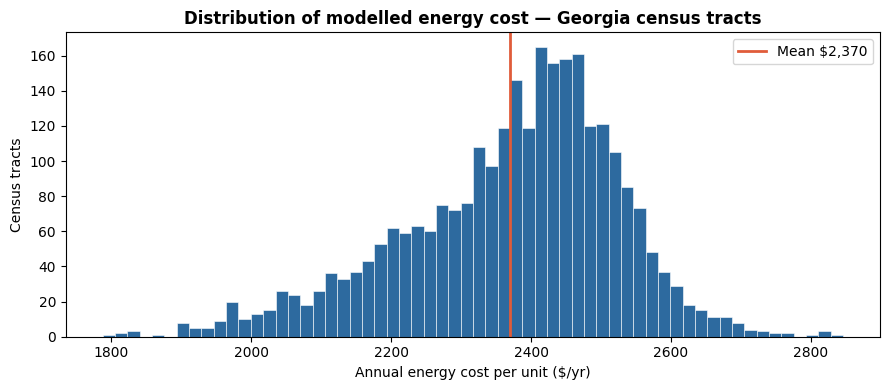

Saved: cost_distribution.png


In [5]:
def get_climate_zone(county_fips):
    return COUNTY_CLIMATE.get(county_fips, '3A')

def compute_tract_cost(row):
    cz    = get_climate_zone(row.get('county', '121'))
    total = row.get('B25032_001E', 1) or 1
    weights = {
        'Single-Family Detached':  row.get('B25032_003E',0)+row.get('B25032_013E',0),
        'Single-Family Attached':  row.get('B25032_004E',0)+row.get('B25032_014E',0),
        'Multi-Family 2-4 Unit':   row.get('B25032_005E',0)+row.get('B25032_015E',0),
        'Multi-Family 5+ Unit':    sum(row.get(c,0) for c in [
            'B25032_006E','B25032_007E','B25032_008E','B25032_009E',
            'B25032_016E','B25032_017E','B25032_018E','B25032_019E']),
        'Mobile Home':             row.get('B25032_010E',0)+row.get('B25032_020E',0),
    }
    unit_total = sum(weights.values()) or total
    # pre-1980 stock runs ~20% higher energy use
    age_mult = 1.0 + 0.20 * (row.get('pct_pre1980') or 0.0)
    cost = sum((cnt/unit_total)*compute_unit_cost(bt,cz) for bt,cnt in weights.items()) * age_mult
    return round(cost, 2)

if acs is not None:
    print('Computing target variable for all tracts...')
    acs_feat['target_cost_usd'] = acs_feat.apply(compute_tract_cost, axis=1)
    print(f'Target stats:')
    print(acs_feat['target_cost_usd'].describe().to_string())

    fig, ax = plt.subplots(figsize=(9,4))
    ax.hist(acs_feat['target_cost_usd'].dropna(), bins=60, color='#2d6a9f', edgecolor='white', linewidth=0.4)
    ax.axvline(acs_feat['target_cost_usd'].mean(), color='#e05c3a', linewidth=2,
               label=f'Mean ${acs_feat["target_cost_usd"].mean():,.0f}')
    ax.set_xlabel('Annual energy cost per unit ($/yr)')
    ax.set_ylabel('Census tracts')
    ax.set_title('Distribution of modelled energy cost — Georgia census tracts', fontweight='bold')
    ax.legend(); plt.tight_layout()
    plt.savefig('cost_distribution.png', dpi=150, bbox_inches='tight')
    plt.show(); print('Saved: cost_distribution.png')


## 5 · Train Gradient Boosting Regressor

The model learns which combinations of housing age, fuel type, building mix, and income
drive energy costs — without being explicitly programmed with the ResStock cost table.

**Hyperparameters**: 300 estimators, lr=0.05, max_depth=4, subsample=0.8

In [6]:
FEATURE_COLS = [
    'pct_elec_heat','pct_gas_heat','pct_propane_heat','pct_no_fuel',
    'pct_pre1980','pct_post2000','mean_vintage_year',
    'pct_sf_detached','pct_sf_attached','pct_mf_small','pct_mf_large','pct_mobile',
    'pct_owner_occupied','log_income','poverty_rate',
]
TARGET = 'target_cost_usd'

if acs is not None:
    ml_df = acs_feat[FEATURE_COLS + [TARGET,'GEOID','county','median_income']].copy()
    ml_df = ml_df.replace([np.inf,-np.inf], np.nan).dropna(subset=FEATURE_COLS+[TARGET])
    ml_df = ml_df[(ml_df[TARGET]>500) & (ml_df[TARGET]<30000)]
    print(f'Training on {len(ml_df):,} tracts')

    X = ml_df[FEATURE_COLS].values
    y = ml_df[TARGET].values
    X_train,X_test,y_train,y_test,idx_train,idx_test = train_test_split(
        X, y, ml_df.index, test_size=0.20, random_state=42
    )

    gbr = GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        min_samples_leaf=5, subsample=0.8, random_state=42
    )
    gbr.fit(X_train, y_train)

    y_pred_test = gbr.predict(X_test)
    r2  = r2_score(y_test, y_pred_test)
    mae = mean_absolute_error(y_test, y_pred_test)
    cv  = cross_val_score(gbr, X, y, cv=5, scoring='r2')

    print(f'\nModel performance')
    print(f'  R2  (test):      {r2:.3f}')
    print(f'  MAE (test):      ${mae:,.0f} / unit / year')
    print(f'  R2  (5-fold CV): {cv.mean():.3f} +/- {cv.std():.3f}')

    ml_df = ml_df.copy()
    ml_df['predicted_cost'] = gbr.predict(X)
    ml_df['in_test_set']    = ml_df.index.isin(idx_test)
    print(f'\nPredictions generated for all {len(ml_df):,} tracts.')


Training on 2,766 tracts

Model performance
  R2  (test):      0.988
  MAE (test):      $11 / unit / year
  R2  (5-fold CV): 0.985 +/- 0.004

Predictions generated for all 2,766 tracts.


## 6 · Feature importance

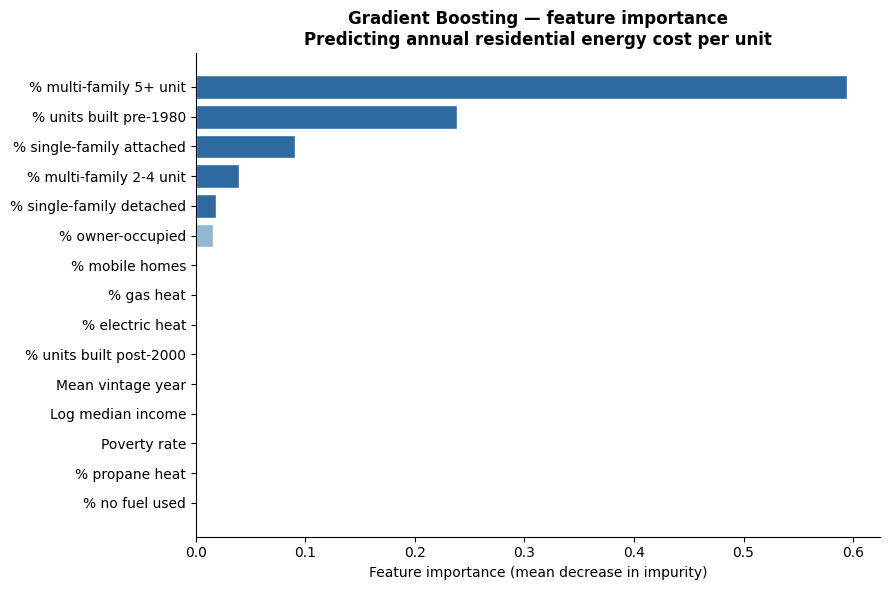

Saved: feature_importance.png


In [7]:
FEAT_LABELS = {
    'pct_elec_heat':     '% electric heat',
    'pct_gas_heat':      '% gas heat',
    'pct_propane_heat':  '% propane heat',
    'pct_no_fuel':       '% no fuel used',
    'pct_pre1980':       '% units built pre-1980',
    'pct_post2000':      '% units built post-2000',
    'mean_vintage_year': 'Mean vintage year',
    'pct_sf_detached':   '% single-family detached',
    'pct_sf_attached':   '% single-family attached',
    'pct_mf_small':      '% multi-family 2-4 unit',
    'pct_mf_large':      '% multi-family 5+ unit',
    'pct_mobile':        '% mobile homes',
    'pct_owner_occupied':'% owner-occupied',
    'log_income':        'Log median income',
    'poverty_rate':      'Poverty rate',
}

if acs is not None:
    fi = pd.DataFrame({'feature':[FEAT_LABELS[f] for f in FEATURE_COLS],
                       'importance':gbr.feature_importances_}).sort_values('importance')

    fig, ax = plt.subplots(figsize=(9,6))
    colors = ['#2d6a9f' if i >= len(fi)-5 else '#90b8d4' for i in range(len(fi))]
    ax.barh(fi['feature'], fi['importance'], color=colors, edgecolor='white')
    ax.set_xlabel('Feature importance (mean decrease in impurity)')
    ax.set_title('Gradient Boosting — feature importance\nPredicting annual residential energy cost per unit',
                 fontweight='bold')
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show(); print('Saved: feature_importance.png')


## 7 · Model diagnostics — predicted vs. actual

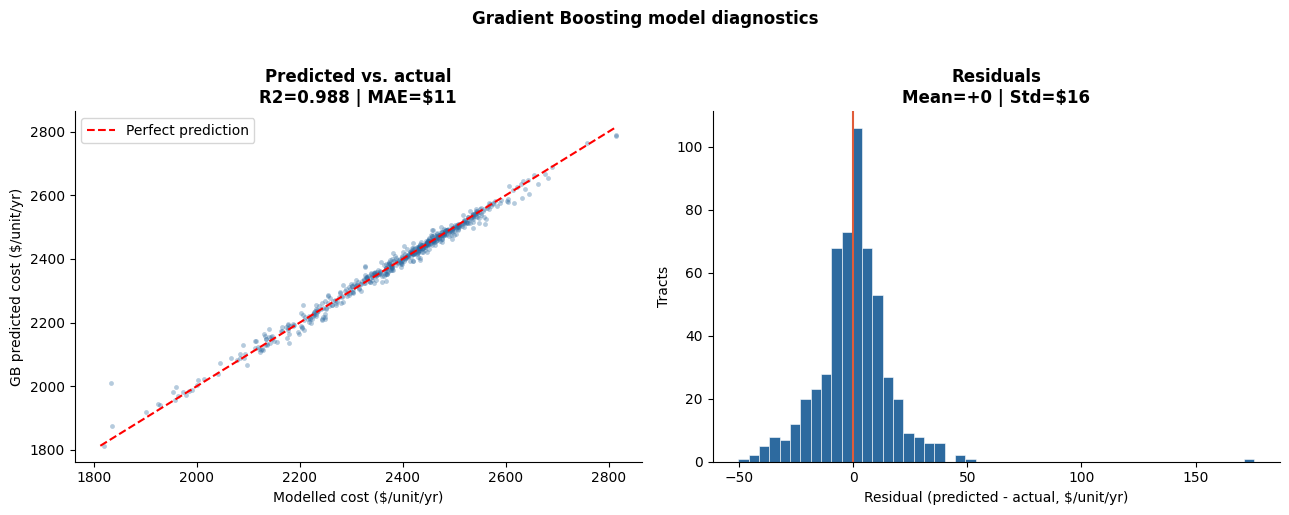

Saved: model_diagnostics.png


In [8]:
if acs is not None:
    fig, axes = plt.subplots(1,2,figsize=(13,5))

    ax = axes[0]
    ax.scatter(y_test, y_pred_test, alpha=0.35, s=12, color='#2d6a9f', linewidths=0)
    mn,mx = min(y_test.min(),y_pred_test.min()), max(y_test.max(),y_pred_test.max())
    ax.plot([mn,mx],[mn,mx],'r--',linewidth=1.5,label='Perfect prediction')
    ax.set_xlabel('Modelled cost ($/unit/yr)'); ax.set_ylabel('GB predicted cost ($/unit/yr)')
    ax.set_title(f'Predicted vs. actual\nR2={r2:.3f} | MAE=${mae:,.0f}', fontweight='bold')
    ax.legend(); ax.spines[['top','right']].set_visible(False)

    ax2 = axes[1]
    residuals = y_pred_test - y_test
    ax2.hist(residuals, bins=50, color='#2d6a9f', edgecolor='white', linewidth=0.4)
    ax2.axvline(0, color='#e05c3a', linewidth=1.5)
    ax2.set_xlabel('Residual (predicted - actual, $/unit/yr)')
    ax2.set_ylabel('Tracts')
    ax2.set_title(f'Residuals\nMean={residuals.mean():+.0f} | Std=${residuals.std():,.0f}', fontweight='bold')
    ax2.spines[['top','right']].set_visible(False)

    plt.suptitle('Gradient Boosting model diagnostics', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('model_diagnostics.png', dpi=150, bbox_inches='tight')
    plt.show(); print('Saved: model_diagnostics.png')


## 8 · Energy burden

Energy burden = predicted annual cost / median household income x 100

HUD thresholds: <3% low | 3-6% moderate | >=6% severe

In [9]:
if acs is not None:
    ml_df['energy_burden_pct'] = (
        ml_df['predicted_cost'] / ml_df['median_income'].replace(0,np.nan) * 100
    ).clip(upper=30)

    cuts   = [0,3,6,10,30]
    labels = ['Low (<3%)','Moderate (3-6%)','Severe (6-10%)','Extreme (>10%)']
    ml_df['burden_tier'] = pd.cut(ml_df['energy_burden_pct'], bins=cuts, labels=labels)

    print('Energy burden distribution across Georgia tracts:')
    for tier, cnt in ml_df['burden_tier'].value_counts().sort_index().items():
        pct = cnt/len(ml_df)*100
        print(f'  {str(tier):<22} {cnt:>5} tracts  {pct:4.1f}%  {"#"*int(pct/2)}')
    print(f'\n  Median burden:           {ml_df["energy_burden_pct"].median():.1f}%')
    print(f'  Tracts with severe (>=6%): {(ml_df["energy_burden_pct"]>=6).sum():,}')


Energy burden distribution across Georgia tracts:
  Low (<3%)               1128 tracts  40.8%  ####################
  Moderate (3-6%)         1394 tracts  50.4%  #########################
  Severe (6-10%)           206 tracts   7.4%  ###
  Extreme (>10%)            38 tracts   1.4%  

  Median burden:           3.3%
  Tracts with severe (>=6%): 244


## 9 · Interactive choropleth map

In [10]:
if acs is not None:
    print('Downloading Georgia tract boundaries from Census TIGER...')
    r = requests.get('https://www2.census.gov/geo/tiger/TIGER2023/TRACT/tl_2023_13_tract.zip', timeout=120)
    with open('/tmp/ga_tracts.zip','wb') as f: f.write(r.content)
    gdf = gpd.read_file('/tmp/ga_tracts.zip')
    gdf = gdf.merge(ml_df[['GEOID','predicted_cost','energy_burden_pct','median_income']], on='GEOID', how='left')
    print(f'Matched: {gdf["predicted_cost"].notna().sum():,} / {len(gdf):,} tracts')

    m = folium.Map(location=[32.8,-83.4], zoom_start=7, tiles='CartoDB positron', prefer_canvas=True)

    # Layer 1: energy cost
    folium.Choropleth(
        geo_data=gdf.__geo_interface__,
        data=gdf[['GEOID','predicted_cost']].dropna(),
        columns=['GEOID','predicted_cost'],
        key_on='feature.properties.GEOID',
        fill_color='YlOrRd', fill_opacity=0.75, line_opacity=0.15, line_weight=0.3,
        nan_fill_color='lightgray', nan_fill_opacity=0.3,
        legend_name='Predicted annual energy cost ($/unit/yr)',
        name='Energy cost',
    ).add_to(m)

    # Layer 2: energy burden
    folium.Choropleth(
        geo_data=gdf.__geo_interface__,
        data=gdf[['GEOID','energy_burden_pct']].dropna(),
        columns=['GEOID','energy_burden_pct'],
        key_on='feature.properties.GEOID',
        fill_color='PuRd', fill_opacity=0.75, line_opacity=0.15, line_weight=0.3,
        nan_fill_color='lightgray', nan_fill_opacity=0.3,
        legend_name='Energy burden (% of median HH income)',
        name='Energy burden',
    ).add_to(m)

    # Tooltip
    tip_gdf = gdf[['GEOID','predicted_cost','energy_burden_pct','median_income','geometry']].copy()
    tip_gdf['predicted_cost'] = tip_gdf['predicted_cost'].round(0).astype('Int64')
    tip_gdf['energy_burden_pct'] = tip_gdf['energy_burden_pct'].round(1)
    tip_gdf['median_income'] = tip_gdf['median_income'].astype('Int64')
    folium.GeoJson(
        tip_gdf.__geo_interface__,
        style_function=lambda x: {'fillColor':'transparent','color':'transparent','weight':0},
        tooltip=GeoJsonTooltip(
            fields=['GEOID','predicted_cost','energy_burden_pct','median_income'],
            aliases=['Census Tract:','Est. annual cost ($):','Energy burden (%):','Median income ($):'],
            localize=True, sticky=True,
        )
    ).add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)
    m.save('ga_energy_cost_map.html')
    print('Map saved: ga_energy_cost_map.html')

    from IPython.display import IFrame
    IFrame('ga_energy_cost_map.html', width='100%', height=550)


Matched: 2,766 / 2,796 tracts
Map saved: ga_energy_cost_map.html


## 10 · Export

In [11]:
if acs is not None:
    out_cols = ['GEOID','predicted_cost','energy_burden_pct','burden_tier',
                'median_income','pct_pre1980','pct_elec_heat','pct_sf_detached',
                'pct_mobile','poverty_rate']
    out = ml_df[[c for c in out_cols if c in ml_df.columns]]
    out.to_csv('ga_energy_cost_tracts.csv', index=False)
    print(f'Exported: ga_energy_cost_tracts.csv ({len(out):,} rows)')
    print('\nTop 10 highest-cost tracts:')
    print(out.nlargest(10,'predicted_cost')[['GEOID','predicted_cost','energy_burden_pct','pct_pre1980','pct_mobile']].to_string(index=False))


Exported: ga_energy_cost_tracts.csv (2,766 rows)

Top 10 highest-cost tracts:
      GEOID  predicted_cost  energy_burden_pct  pct_pre1980  pct_mobile
13215001100     2830.141573           2.254716     0.857287    0.000000
13089021229     2809.474831           1.586790     0.865823    0.000000
13121010204     2795.558897           1.597654     0.708791    0.000000
13089021703     2787.945021           1.405264     0.787478    0.000000
13089021210     2786.769715           1.298479     0.777885    0.000000
13135050461     2776.038153           5.719898     0.692687    0.000000
13089021228     2764.827307           1.156744     0.679245    0.000000
13089021213     2751.466501           1.175840     0.615635    0.008251
13067030357     2739.501441           1.707184     0.634146    0.000000
13169030106     2738.970727           5.305307     0.670769    0.000000


DAy 2

In [13]:
UPGRADE_SAVINGS = {
    'Single-Family Detached': {
        1: {'savings_usd': 280, 'label': 'Basic envelope'},
        2: {'savings_usd': 420, 'label': 'Enhanced envelope'},
        3: {'savings_usd': 780, 'label': 'Heat pump + envelope'},
    },
    'Single-Family Attached': {
        1: {'savings_usd': 195}, 2: {'savings_usd': 290}, 3: {'savings_usd': 540},
    },
    'Multi-Family 2-4 Unit': {
        1: {'savings_usd': 145}, 2: {'savings_usd': 210}, 3: {'savings_usd': 390},
    },
    'Multi-Family 5+ Unit': {
        1: {'savings_usd': 120}, 2: {'savings_usd': 175}, 3: {'savings_usd': 320},
    },
    'Mobile Home': {
        1: {'savings_usd': 310}, 2: {'savings_usd': 460}, 3: {'savings_usd': 850},
    },
}
UPGRADE_COSTS = {1: 3500, 2: 7000, 3: 14000}
IRA_CREDIT_PCT = 0.0
IRA_CAPS = {1: 1200, 2: 1200, 3: 2000}

def effective_upgrade_cost(uid):
    gross = UPGRADE_COSTS[uid]
    return round(gross - min(gross * IRA_CREDIT_PCT, IRA_CAPS[uid]), 0)

for uid in [1,2,3]:
    g = UPGRADE_COSTS[uid]; e = effective_upgrade_cost(uid)
    print(f'Upgrade {uid}: ${g:,} gross -> ${e:,.0f} after IRA credit')

Upgrade 1: $3,500 gross -> $3,500 after IRA credit
Upgrade 2: $7,000 gross -> $7,000 after IRA credit
Upgrade 3: $14,000 gross -> $14,000 after IRA credit


In [14]:
def compute_tract_upgrade_savings(row, upgrade_id):
    total = row.get('B25032_001E', 1) or 1
    weights = {
        'Single-Family Detached':  row.get('B25032_003E',0)+row.get('B25032_013E',0),
        'Single-Family Attached':  row.get('B25032_004E',0)+row.get('B25032_014E',0),
        'Multi-Family 2-4 Unit':   row.get('B25032_005E',0)+row.get('B25032_015E',0),
        'Multi-Family 5+ Unit':    sum(row.get(c,0) for c in [
            'B25032_006E','B25032_007E','B25032_008E','B25032_009E',
            'B25032_016E','B25032_017E','B25032_018E','B25032_019E']),
        'Mobile Home': row.get('B25032_010E',0)+row.get('B25032_020E',0),
    }
    unit_total = sum(weights.values()) or total
    age_mult = 1.0 + 0.15 * (row.get('pct_pre1980') or 0.0)
    savings = sum(
        (cnt/unit_total) * UPGRADE_SAVINGS.get(bt, UPGRADE_SAVINGS['Single-Family Detached'])[upgrade_id]['savings_usd']
        for bt, cnt in weights.items()
    ) * age_mult
    return round(savings, 2)

struct_cols = [
    'B25032_001E','B25032_003E','B25032_004E','B25032_005E','B25032_006E',
    'B25032_007E','B25032_008E','B25032_009E','B25032_010E',
    'B25032_013E','B25032_014E','B25032_015E','B25032_016E',
    'B25032_017E','B25032_018E','B25032_019E','B25032_020E',
    'B25001_001E','pct_pre1980','county',
]
savings_df = ml_df.join(
    acs_feat[[c for c in struct_cols if c in acs_feat.columns]],
    how='left', rsuffix='_acs'
)

for uid in [1,2,3]:
    savings_df[f'savings_u{uid}_usd'] = savings_df.apply(
        lambda r: compute_tract_upgrade_savings(r, uid), axis=1)
    eff = effective_upgrade_cost(uid)
    savings_df[f'payback_u{uid}_yrs'] = (eff / savings_df[f'savings_u{uid}_usd'].replace(0,np.nan)).round(1)
    savings_df[f'burden_reduction_u{uid}_pct'] = (
        savings_df[f'savings_u{uid}_usd'] / savings_df['median_income'].replace(0,np.nan) * 100).round(2)
    print(f'Upgrade {uid}: mean savings ${savings_df[f"savings_u{uid}_usd"].mean():,.0f}/yr | '
          f'median payback {savings_df[f"payback_u{uid}_yrs"].median():.1f} yrs')

savings_df['best_savings_usd'] = savings_df[['savings_u1_usd','savings_u2_usd','savings_u3_usd']].max(axis=1)
savings_df['best_payback_yrs'] = savings_df[['payback_u1_yrs','payback_u2_yrs','payback_u3_yrs']].min(axis=1)
print(f'\nDone. {len(savings_df):,} tracts.')

Upgrade 1: mean savings $265/yr | median payback 13.0 yrs
Upgrade 2: mean savings $397/yr | median payback 17.4 yrs
Upgrade 3: mean savings $737/yr | median payback 18.7 yrs

Done. 2,766 tracts.


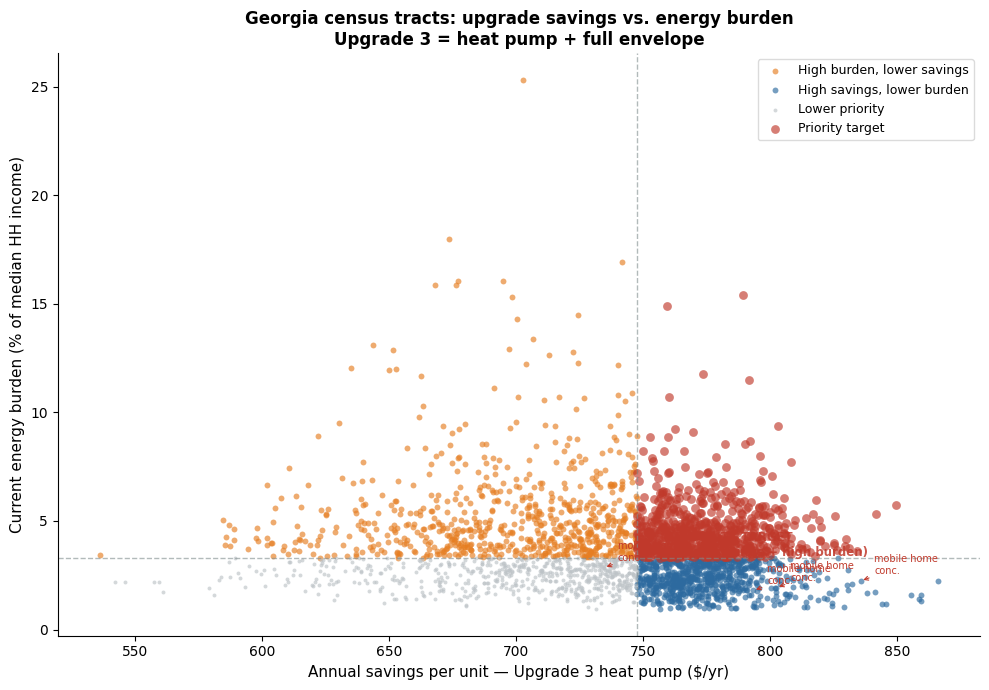

Priority tracts: 643


In [16]:
plot_df = savings_df[['savings_u3_usd','energy_burden_pct','pct_mobile','pct_pre1980','median_income','GEOID']].dropna()
med_savings = plot_df['savings_u3_usd'].median()
med_burden  = plot_df['energy_burden_pct'].median()

def quadrant(row):
    hi_s = row['savings_u3_usd'] >= med_savings
    hi_b = row['energy_burden_pct'] >= med_burden
    if hi_s and hi_b:     return 'Priority target'
    if hi_s and not hi_b: return 'High savings, lower burden'
    if not hi_s and hi_b: return 'High burden, lower savings'
    return 'Lower priority'

plot_df = plot_df.copy()
plot_df['quad'] = plot_df.apply(quadrant, axis=1)

colors = {
    'Priority target':            '#c0392b',
    'High savings, lower burden': '#2d6a9f',
    'High burden, lower savings': '#e67e22',
    'Lower priority':             '#bdc3c7',
}
sizes = {'Priority target':40,'High savings, lower burden':18,'High burden, lower savings':18,'Lower priority':8}

fig, ax = plt.subplots(figsize=(10,7))
for quad, grp in plot_df.groupby('quad'):
    ax.scatter(grp['savings_u3_usd'], grp['energy_burden_pct'],
               c=colors[quad], s=sizes[quad], alpha=0.65, linewidths=0, label=quad)

ax.axvline(med_savings, color='#7f8c8d', linewidth=1, linestyle='--', alpha=0.6)
ax.axhline(med_burden,  color='#7f8c8d', linewidth=1, linestyle='--', alpha=0.6)
ax.text(med_savings*1.02, med_burden*1.02,
        'PRIORITY TARGET\n(high savings + high burden)',
        fontsize=8.5, color='#c0392b', fontweight='bold', alpha=0.85)

# Annotate mobile home tracts
mobile_top = plot_df[plot_df['pct_mobile'] > 0.4].nlargest(5,'savings_u3_usd')
for _, r in mobile_top.iterrows():
    ax.annotate('mobile home\nconc.', xy=(r['savings_u3_usd'], r['energy_burden_pct']),
                xytext=(10,5), textcoords='offset points', fontsize=7, color='#c0392b',
                arrowprops=dict(arrowstyle='->', color='#c0392b', lw=0.8))

ax.set_xlabel('Annual savings per unit — Upgrade 3 heat pump ($/yr)', fontsize=11)
ax.set_ylabel('Current energy burden (% of median HH income)', fontsize=11)
ax.set_title('Georgia census tracts: upgrade savings vs. energy burden\n'
             'Upgrade 3 = heat pump + full envelope',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, framealpha=0.7)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('upgrade_roi_quadrant.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Priority tracts: {(plot_df['quad']=='Priority target').sum():,}")

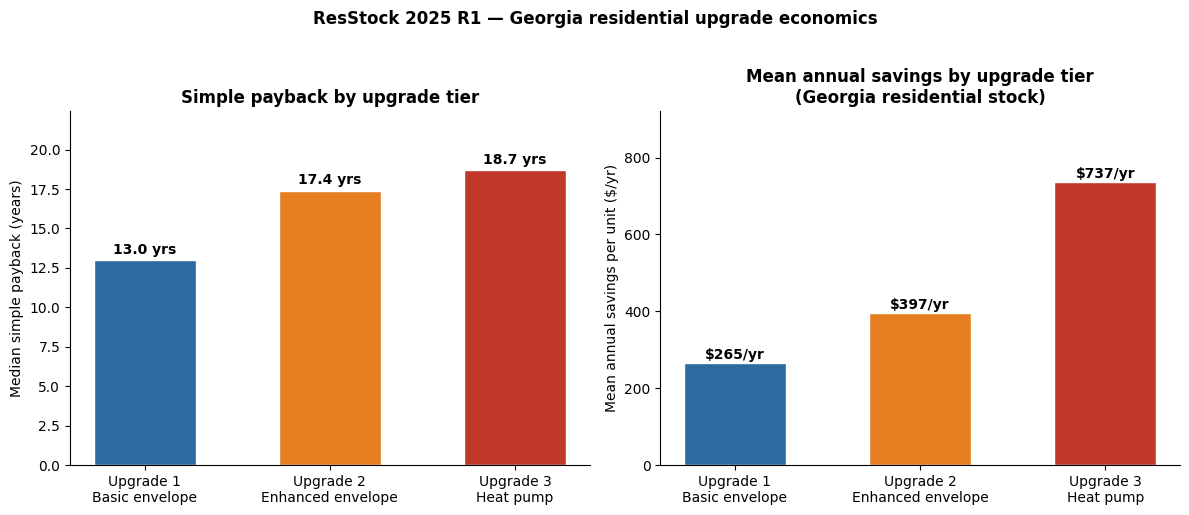

In [18]:
summary = pd.DataFrame({
    'Upgrade': ['Upgrade 1\nBasic envelope','Upgrade 2\nEnhanced envelope','Upgrade 3\nHeat pump'],
    'Effective cost': [effective_upgrade_cost(u) for u in [1,2,3]],
    'Median payback': [savings_df[f'payback_u{u}_yrs'].median() for u in [1,2,3]],
    'Mean savings':   [savings_df[f'savings_u{u}_usd'].mean()   for u in [1,2,3]],
})

fig, axes = plt.subplots(1,2,figsize=(12,5))
bar_colors = ['#2d6a9f','#e67e22','#c0392b']

ax = axes[0]
bars = ax.bar(summary['Upgrade'], summary['Median payback'], color=bar_colors, edgecolor='white', width=0.55)
for bar, val in zip(bars, summary['Median payback']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f'{val:.1f} yrs', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Median simple payback (years)')
ax.set_title('Simple payback by upgrade tier', fontweight='bold')
ax.spines[['top','right']].set_visible(False)
ax.set_ylim(0, summary['Median payback'].max()*1.2)

ax2 = axes[1]
bars2 = ax2.bar(summary['Upgrade'], summary['Mean savings'], color=bar_colors, edgecolor='white', width=0.55)
for bar, val in zip(bars2, summary['Mean savings']):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
             f'${val:,.0f}/yr', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_ylabel('Mean annual savings per unit ($/yr)')
ax2.set_title('Mean annual savings by upgrade tier\n(Georgia residential stock)', fontweight='bold')
ax2.spines[['top','right']].set_visible(False)
ax2.set_ylim(0, summary['Mean savings'].max()*1.25)

plt.suptitle('ResStock 2025 R1 — Georgia residential upgrade economics',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('payback_by_tier.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
gdf_upg = gdf.merge(
    savings_df[['GEOID','savings_u3_usd','payback_u3_yrs']].drop_duplicates('GEOID'),
    on='GEOID', how='left'
)

m2 = folium.Map(location=[32.8,-83.4], zoom_start=7, tiles='CartoDB positron', prefer_canvas=True)

folium.Choropleth(
    geo_data=gdf_upg.__geo_interface__,
    data=gdf_upg[['GEOID','savings_u3_usd']].dropna(),
    columns=['GEOID','savings_u3_usd'],
    key_on='feature.properties.GEOID',
    fill_color='YlGn', fill_opacity=0.75, line_opacity=0.12, line_weight=0.3,
    nan_fill_color='lightgray', legend_name='Upgrade 3 annual savings ($/unit/yr)', name='U3 savings',
).add_to(m2)

folium.Choropleth(
    geo_data=gdf_upg.__geo_interface__,
    data=gdf_upg[['GEOID','payback_u3_yrs']].dropna(),
    columns=['GEOID','payback_u3_yrs'],
    key_on='feature.properties.GEOID',
    fill_color='RdYlGn_r', fill_opacity=0.75, line_opacity=0.12, line_weight=0.3,
    nan_fill_color='lightgray', legend_name='Payback — Upgrade 3 (years, post-IRA)', name='Payback (yrs)',
).add_to(m2)

tip = gdf_upg[['GEOID','predicted_cost','savings_u3_usd','payback_u3_yrs','energy_burden_pct','geometry']].copy()
tip['savings_u3_usd'] = tip['savings_u3_usd'].round(0).astype('Int64')
tip['payback_u3_yrs'] = tip['payback_u3_yrs'].round(1)
tip['energy_burden_pct'] = tip['energy_burden_pct'].round(1)

folium.GeoJson(
    tip.__geo_interface__,
    style_function=lambda x: {'fillColor':'transparent','color':'transparent','weight':0},
    tooltip=GeoJsonTooltip(
        fields=['GEOID','predicted_cost','savings_u3_usd','payback_u3_yrs','energy_burden_pct'],
        aliases=['Tract:','Baseline cost ($):','U3 savings ($/yr):','Payback (yrs):','Burden (%):'],
        localize=True, sticky=True,
    )
).add_to(m2)

folium.LayerControl(collapsed=False).add_to(m2)
m2.save('ga_upgrade_savings_map.html')
print('Saved: ga_upgrade_savings_map.html')
from IPython.display import IFrame
IFrame('ga_upgrade_savings_map.html', width='100%', height=550)

Saved: ga_upgrade_savings_map.html


In [20]:
total_units   = acs_feat['B25001_001E'].sum()
priority_n    = (savings_df['energy_burden_pct'] >= 6).sum()
median_pb     = savings_df['payback_u3_yrs'].median()

print('=== Georgia statewide upgrade potential ===')
print(f'  Total housing units modelled:     {total_units:>12,.0f}')
print(f'  Priority tracts (burden >= 6%):   {priority_n:>12,}')
print(f'  Median U3 payback (post-IRA):     {median_pb:>11.1f} yrs')
print()
print('Outputs saved:')
print('  upgrade_roi_quadrant.png  <- LinkedIn hero image')
print('  payback_by_tier.png       <- supporting chart')
print('  ga_upgrade_savings_map.html <- interactive map')

=== Georgia statewide upgrade potential ===
  Total housing units modelled:        4,483,873
  Priority tracts (burden >= 6%):            244
  Median U3 payback (post-IRA):            18.7 yrs

Outputs saved:
  upgrade_roi_quadrant.png  <- LinkedIn hero image
  payback_by_tier.png       <- supporting chart
  ga_upgrade_savings_map.html <- interactive map


In [22]:
county_df = savings_df.copy()
if 'county' not in county_df.columns:
    county_df['county'] = county_df['GEOID'].str[2:5]

agg = county_df.groupby('county').agg(
    n_tracts            = ('GEOID',             'count'),
    median_burden       = ('energy_burden_pct',  'median'),
    pct_severe_burden   = ('energy_burden_pct',  lambda x: (x >= 6).mean() * 100),
    mean_pre1980        = ('pct_pre1980',         'mean'),
    mean_mobile         = ('pct_mobile',          'mean'),
    mean_savings_u1     = ('savings_u1_usd',      'mean'),
    mean_savings_u3     = ('savings_u3_usd',      'mean'),
    median_income       = ('median_income',       'median'),
    mean_predicted_cost = ('predicted_cost',      'mean'),
    mean_payback_u1     = ('payback_u1_yrs',      'median'),
).reset_index()

COUNTY_NAMES = {
    '001':'Appling','003':'Atkinson','005':'Bacon','007':'Baker','009':'Baldwin',
    '011':'Banks','013':'Barrow','015':'Bartow','017':'Ben Hill','019':'Berrien',
    '021':'Bibb','023':'Bleckley','025':'Brantley','027':'Brooks','029':'Bryan',
    '031':'Bulloch','033':'Burke','035':'Butts','037':'Calhoun','039':'Camden',
    '041':'Candler','043':'Carroll','045':'Catoosa','047':'Charlton','049':'Chatham',
    '051':'Chattahoochee','053':'Chattooga','055':'Cherokee','057':'Clarke',
    '059':'Clay','061':'Clayton','063':'Clinch','065':'Cobb','067':'Coffee',
    '069':'Colquitt','071':'Columbia','073':'Cook','075':'Coweta','077':'Crawford',
    '079':'Crisp','081':'Dade','083':'Dawson','085':'Decatur','087':'DeKalb',
    '089':'Dodge','091':'Dooly','093':'Dougherty','095':'Douglas','097':'Early',
    '099':'Echols','101':'Effingham','103':'Elbert','105':'Emanuel','107':'Evans',
    '109':'Fannin','111':'Fayette','113':'Floyd','115':'Forsyth','117':'Franklin',
    '119':'Fulton','121':'Gilmer','123':'Glascock','125':'Glynn','127':'Gordon',
    '129':'Grady','131':'Greene','133':'Gwinnett','135':'Habersham','137':'Hall',
    '139':'Hancock','141':'Haralson','143':'Harris','145':'Hart','147':'Heard',
    '149':'Henry','151':'Houston','153':'Irwin','155':'Jackson','157':'Jasper',
    '159':'Jeff Davis','161':'Jefferson','163':'Jenkins','165':'Johnson',
    '167':'Jones','169':'Lamar','171':'Lanier','173':'Laurens','175':'Lee',
    '177':'Liberty','179':'Lincoln','181':'Long','183':'Lowndes','185':'Lumpkin',
    '187':'McDuffie','189':'McIntosh','191':'Meriwether','193':'Miller',
    '195':'Mitchell','197':'Monroe','199':'Montgomery','201':'Morgan','203':'Murray',
    '205':'Muscogee','207':'Newton','209':'Oconee','211':'Oglethorpe','213':'Paulding',
    '215':'Peach','217':'Pickens','219':'Pierce','221':'Pike','223':'Polk',
    '225':'Pulaski','227':'Putnam','229':'Quitman','231':'Rabun','233':'Randolph',
    '235':'Richmond','237':'Rockdale','239':'Schley','241':'Screven','243':'Seminole',
    '245':'Spalding','247':'Stephens','249':'Stewart','251':'Sumter','253':'Talbot',
    '255':'Taliaferro','257':'Tattnall','259':'Taylor','261':'Telfair','263':'Terrell',
    '265':'Thomas','267':'Tift','269':'Toombs','271':'Towns','273':'Treutlen',
    '275':'Troup','277':'Turner','279':'Twiggs','281':'Union','283':'Upson',
    '285':'Walker','287':'Walton','289':'Ware','291':'Warren','293':'Washington',
    '295':'Wayne','297':'Webster','299':'Wheeler','301':'White','303':'Whitfield',
    '305':'Wilcox','307':'Wilkes','309':'Wilkinson','311':'Worth',
}

agg['county_name'] = agg['county'].map(COUNTY_NAMES).fillna('Unknown')
print(f'County aggregates built: {len(agg)} counties')

County aggregates built: 159 counties


In [23]:
def minmax(series):
    mn, mx = series.min(), series.max()
    if mx == mn: return pd.Series(0.5, index=series.index)
    return (series - mn) / (mx - mn)

score_df = agg.copy()

score_df['s_burden']  = minmax(score_df['median_burden'])       # higher = worse
score_df['s_pre1980'] = minmax(score_df['mean_pre1980'])        # higher = worse
score_df['s_mobile']  = minmax(score_df['mean_mobile'])         # higher = worse
score_df['s_savings'] = minmax(score_df['mean_savings_u1'])     # higher = better
score_df['s_income']  = 1 - minmax(score_df['median_income'])   # lower income = worse

score_df['priority_score'] = (
    0.35 * score_df['s_burden']  +
    0.25 * score_df['s_pre1980'] +
    0.20 * score_df['s_mobile']  +
    0.10 * score_df['s_savings'] +
    0.10 * score_df['s_income']
) * 100

def dominant_type(row):
    if row['mean_mobile'] > 0.15:  return 'Mobile home'
    if row['mean_pre1980'] > 0.45: return 'Pre-1980 stock'
    return 'Mixed/other'

score_df['dominant_type'] = score_df.apply(dominant_type, axis=1)
top20 = score_df.nlargest(20, 'priority_score').sort_values('priority_score')

print('Top 20 counties by Weatherization Priority Score:')
print(top20[['county_name','priority_score','median_burden','mean_pre1980',
             'mean_mobile','mean_savings_u1','median_income']].to_string(index=False))

Top 20 counties by Weatherization Priority Score:
county_name  priority_score  median_burden  mean_pre1980  mean_mobile  mean_savings_u1  median_income
     Talbot       50.792218       4.974413      0.473433     0.000000       277.283333        50129.0
      Towns       51.010997       4.777112      0.495758     0.001203       276.084000        50216.0
      Wayne       51.175743       4.495804      0.457534     0.011022       280.526111        56368.5
    Unknown       51.205157       5.687204      0.384149     0.000000       281.190000        45063.0
    Telfair       51.737371       5.625992      0.421231     0.008034       265.471250        41116.5
   Cherokee       52.050119       4.687110      0.477679     0.009445       276.774444        52883.0
    Unknown       52.391805       5.522596      0.407863     0.003992       279.950000        45984.0
     Taylor       52.699133       6.679922      0.355230     0.007634       260.275000        35479.5
      White       54.180785     

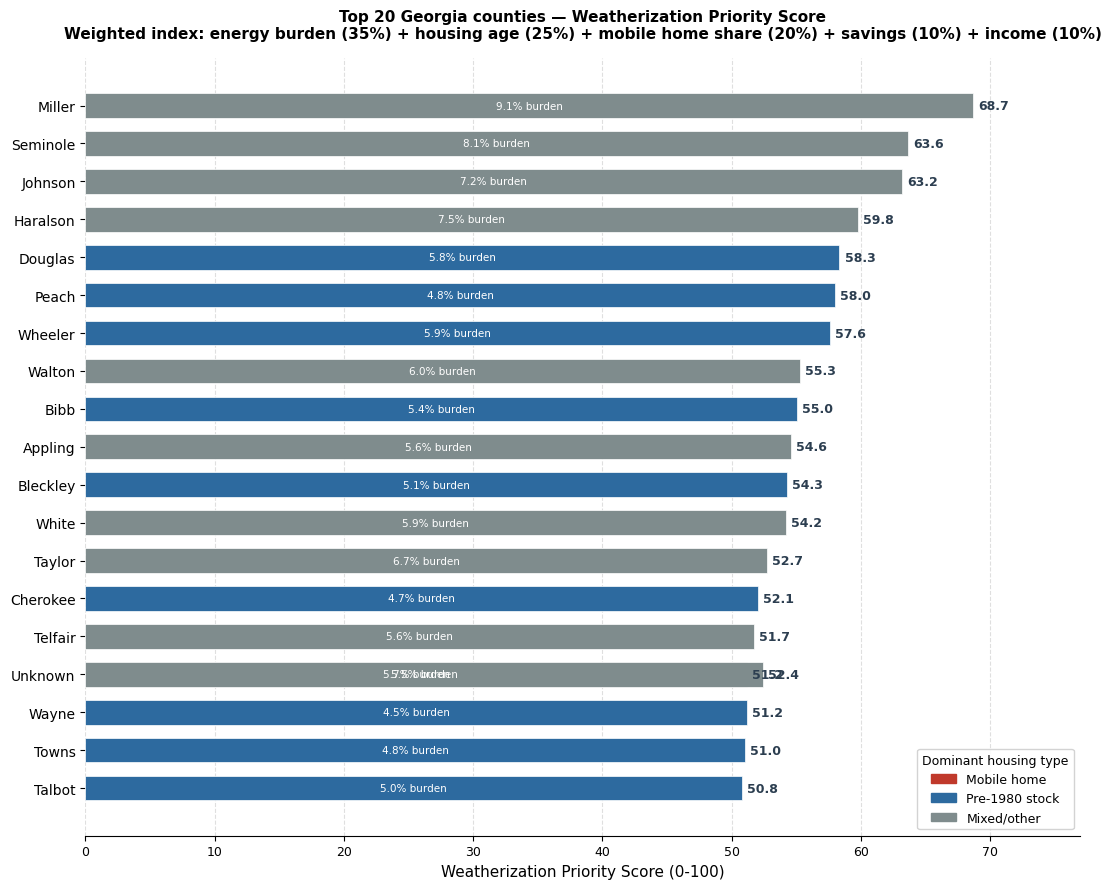

Saved: ga_county_priority_leaderboard.png


In [24]:
import matplotlib.patches as mpatches

type_colors = {
    'Mobile home':    '#c0392b',
    'Pre-1980 stock': '#2d6a9f',
    'Mixed/other':    '#7f8c8d',
}

fig, ax = plt.subplots(figsize=(11, 9))

bars = ax.barh(
    top20['county_name'],
    top20['priority_score'],
    color=[type_colors[t] for t in top20['dominant_type']],
    edgecolor='white', linewidth=0.5, height=0.65,
)

for bar, score, burden in zip(bars, top20['priority_score'], top20['median_burden']):
    # Score at end of bar
    ax.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height()/2,
            f'{score:.1f}', va='center', ha='left',
            fontsize=9, fontweight='bold', color='#2c3e50')
    # Burden % inside bar
    ax.text(bar.get_width() * 0.5, bar.get_y() + bar.get_height()/2,
            f'{burden:.1f}% burden', va='center', ha='center',
            fontsize=7.5, color='white', fontweight='500')

patches = [mpatches.Patch(color=c, label=l) for l, c in type_colors.items()]
ax.legend(handles=patches, title='Dominant housing type',
          fontsize=9, title_fontsize=9, loc='lower right', framealpha=0.85)

ax.set_xlabel('Weatherization Priority Score (0-100)', fontsize=11)
ax.set_title(
    'Top 20 Georgia counties — Weatherization Priority Score\n'
    'Weighted index: energy burden (35%) + housing age (25%) + '
    'mobile home share (20%) + savings (10%) + income (10%)',
    fontsize=11, fontweight='bold', pad=14
)
ax.set_xlim(0, top20['priority_score'].max() * 1.12)
ax.spines[['top','right','left']].set_visible(False)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=9)
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('ga_county_priority_leaderboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ga_county_priority_leaderboard.png')

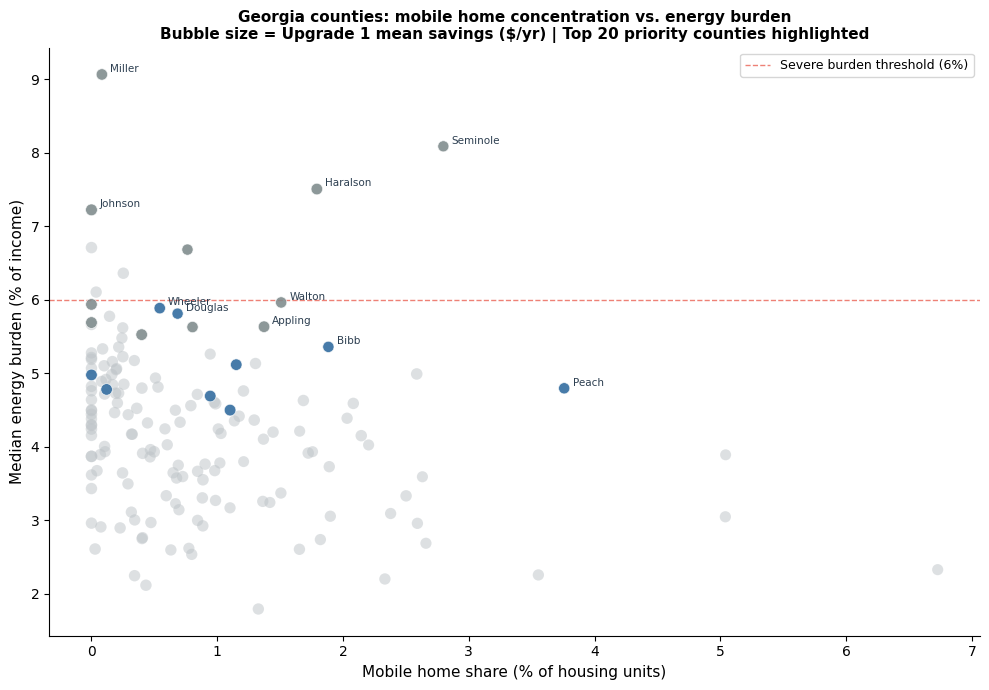

Saved: ga_county_burden_mobile_scatter.png


In [25]:
fig, ax = plt.subplots(figsize=(10, 7))

# All counties in gray
ax.scatter(
    score_df['mean_mobile'] * 100, score_df['median_burden'],
    s=score_df['mean_savings_u1'] / 4,
    color='#bdc3c7', alpha=0.5, linewidths=0, zorder=2
)
# Top 20 highlighted
ax.scatter(
    top20['mean_mobile'] * 100, top20['median_burden'],
    s=top20['mean_savings_u1'] / 4,
    color=[type_colors[t] for t in top20['dominant_type']],
    alpha=0.85, linewidths=0.5, edgecolors='white', zorder=3
)
# Label top 10
for _, row in top20.tail(10).iterrows():
    ax.annotate(row['county_name'],
                xy=(row['mean_mobile']*100, row['median_burden']),
                xytext=(6, 2), textcoords='offset points',
                fontsize=7.5, color='#2c3e50')

ax.axhline(6, color='#e74c3c', linewidth=1, linestyle='--', alpha=0.7,
           label='Severe burden threshold (6%)')
ax.set_xlabel('Mobile home share (% of housing units)', fontsize=11)
ax.set_ylabel('Median energy burden (% of income)', fontsize=11)
ax.set_title(
    'Georgia counties: mobile home concentration vs. energy burden\n'
    'Bubble size = Upgrade 1 mean savings ($/yr) | Top 20 priority counties highlighted',
    fontsize=11, fontweight='bold'
)
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('ga_county_burden_mobile_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ga_county_burden_mobile_scatter.png')

In [26]:
out = score_df[[
    'county','county_name','priority_score','median_burden','pct_severe_burden',
    'mean_pre1980','mean_mobile','mean_savings_u1','mean_payback_u1',
    'median_income','n_tracts','dominant_type'
]].sort_values('priority_score', ascending=False)

out.to_csv('ga_county_weatherization_priority.csv', index=False)
print('Exported: ga_county_weatherization_priority.csv')

print('\nTop 5 counties for the post:')
for i, (_, row) in enumerate(out.head(5).iterrows(), 1):
    print(f'  {i}. {row["county_name"]} County — '
          f'burden {row["median_burden"]:.1f}% | '
          f'mobile home share {row["mean_mobile"]*100:.0f}% | '
          f'score {row["priority_score"]:.1f}')

Exported: ga_county_weatherization_priority.csv

Top 5 counties for the post:
  1. Miller County — burden 9.1% | mobile home share 0% | score 68.7
  2. Seminole County — burden 8.1% | mobile home share 3% | score 63.6
  3. Johnson County — burden 7.2% | mobile home share 0% | score 63.2
  4. Haralson County — burden 7.5% | mobile home share 2% | score 59.8
  5. Douglas County — burden 5.8% | mobile home share 1% | score 58.3
